In [1]:
#First mount Drive for the dataset if it is not mounted or session is restarted.
from google.colab import drive
drive.mount('/content/drive')

: 

In [2]:
#Clone or pull the latest code
import os
REPO = "LaneDetection"
if not os.path.exists(f"/content/{REPO}"):
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/{REPO}
else:
    !cd /content/{REPO} && git pull

%cd /content/{REPO}

Already up to date.
/content/LaneDetection


Dataset length: 2900
Number of batches: 363

imgs        -> shape=(8, 3, 256, 512),        dtype=torch.float32,        min=0.000, max=1.000
bin_masks   -> shape=(8, 1, 256, 512),   dtype=torch.float32,   unique=[0.0, 1.0]
inst_masks  -> shape=(8, 1, 256, 512),  dtype=torch.uint8,  unique=[0, 50, 100, 150, 200, 250]


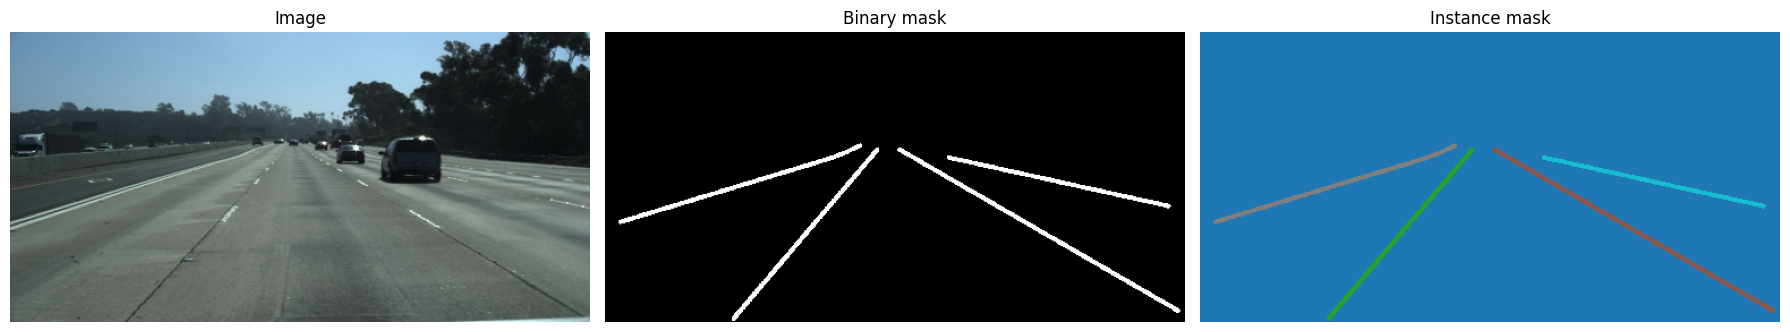

In [5]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image

# 1. Build dataset + loader
manifest = f"{cfg.ROOT_DIR}/train.txt"
dataset = LaneDataset(manifest_path=manifest,
                      root_dir=cfg.ROOT_DIR,
                      transform=transform_image)

loader = DataLoader(dataset,
                    batch_size=cfg.BATCH_SIZE,
                    shuffle=True,
                    num_workers=2)

print(f"Dataset length: {len(dataset)}")
print(f"Number of batches: {len(loader)}")

# 2. Pull one batch and inspect shapes / dtypes / value ranges
imgs, bin_masks, inst_masks = next(iter(loader))

print(f"\nimgs        -> shape={tuple(imgs.shape)},        dtype={imgs.dtype},        min={imgs.min():.3f}, max={imgs.max():.3f}")
print(f"bin_masks   -> shape={tuple(bin_masks.shape)},   dtype={bin_masks.dtype},   unique={torch.unique(bin_masks).tolist()}")
print(f"inst_masks  -> shape={tuple(inst_masks.shape)},  dtype={inst_masks.dtype},  unique={torch.unique(inst_masks).tolist()}")

# Expected for batch_size=8, 256x512:
#   imgs       (8, 3, 256, 512), float32, [0, 1]
#   bin_masks  (8, 1, 256, 512), float32, [0., 1.]
#   inst_masks (8, 1, 256, 512), float32 or uint8, e.g. [0, 1, 2, 3, 4]

# 3. Visualize one sample from the batch
i = 0  # change to view different samples in the batch

# image: (C, H, W) -> (H, W, C); cv2 loaded BGR so swap to RGB for display
img_np = imgs[i].permute(1, 2, 0).numpy()[:, :, ::-1]
bin_np = bin_masks[i].squeeze(0).numpy()
inst_np = inst_masks[i].squeeze(0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_np); axes[0].set_title("Image"); axes[0].axis("off")
axes[1].imshow(bin_np, cmap="gray"); axes[1].set_title("Binary mask"); axes[1].axis("off")
axes[2].imshow(inst_np, cmap="tab10"); axes[2].set_title("Instance mask"); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import torch
from src.models.encoder import ENetEncoder

enc = ENetEncoder()
x = torch.randn(2, 3, 256, 512)
feats, idx1, idx2, s1, s2, inp = enc(x)

print("features:", feats.shape)        # (2, 128, 32, 64)
print("idx1:    ", idx1.shape)          # (2, 64, 64, 128)
print("idx2:    ", idx2.shape)          # (2, 128, 32, 64)
print("s1:", s1, "  s2:", s2, "  inp:", inp)
print("params:  ", sum(p.numel() for p in enc.parameters()))   # ~310-320k

: 